In [1]:
from qick import *
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=mpl.colormaps['Set1'].colors
)

In [2]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
# from tqdm import tqdm
from tqdm.notebook import tqdm
import xarray as xr

In [3]:
import os
import sys
sys.path.insert(0, '../../pattern/')
sys.path.insert(0, '../../instrument/')

In [4]:
from pathlib import Path

folder_name = Path.cwd().name
data_dir = Path("Z:/labdata/qcdlabs") / folder_name
data_dir.mkdir(parents=True, exist_ok=True)

In [5]:
sys.path.insert(0, '../../pattern/')
from helper_sweep import do_sweep

In [6]:
from xilinx_qick.class_drx import drx
from xilinx_qick.class_rox import rox
from xilinx_qick.class_sweep import sweep
from xilinx_qick.instr_xilinx_v1 import XilinxProg

xilinx_1 = XilinxProg(ip_address="10.0.100.21", mode='AveragerProgram')

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
rfsoc4x2_1 PYRO:obj_3f3d0f5d2e934a07a2444f124252d9c7@10.0.100.21:33243
QICK running on RFSoC4x2, software version 0.2.381

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decima

In [7]:
xilinx_1.reps = int(1)
dr_ch0 = 0
ro_ch0 = 0

ro_ch1 = 1

In [9]:
def set_modulation(xilinx_1,
                          carrier_frequency_hz=None,
                          modulation_frequency_hz = None,
                          modulation_depth=None):

    if carrier_frequency_hz != None:
        xilinx_1.carrier_frequency_hz = carrier_frequency_hz
    else:
        carrier_frequency_hz = xilinx_1.carrier_frequency_hz

    if modulation_frequency_hz != None:
        xilinx_1.modulation_frequency_hz = modulation_frequency_hz
    else:
        modulation_frequency_hz = xilinx_1.modulation_frequency_hz

    if modulation_depth != None:
        xilinx_1.modulation_depth = modulation_depth
    else:
        modulation_depth = xilinx_1.modulation_depth

    # print(carrier_frequency_hz, modulation_frequency_hz, modulation_depth)

    dt = 1/9830.4
    t_gen = np.arange(0, 1.6*2, dt)

    # dt = 1e-3
    # t_gen = np.arange(0, 3, dt)

    s_gen = 1 * np.exp(1j*modulation_depth*np.sin(2*np.pi*modulation_frequency_hz/1e6*t_gen))

    # from scipy.special import jv
    # s_gen = jv(0, modulation_depth)
    # s_gen += jv(1, modulation_depth) * np.exp(1j*2*np.pi*modulation_frequency_hz/1e6*t_gen)
    # s_gen += -jv(1, modulation_depth) * np.exp(-1j*2*np.pi*modulation_frequency_hz/1e6*t_gen)

    dr_readout1 = drx(soc=xilinx_1.soccfg,
                    dr_ch=dr_ch0, ro_ch=ro_ch0, frequency= carrier_frequency_hz / 1e6, gain=0.9, phase=0)

    dr_readout1.wave.add(name='x2', t_data=t_gen, s_data=s_gen, idx=-1, interp_order=1)
    dr_readout1.rox.set(length=1.6, delay=0.5, sleep=1)
    xilinx_1.add(dr_readout1=dr_readout1)

    ro_readout2 = rox(soc=xilinx_1.soccfg, ro_ch=ro_ch1, dr_ch=dr_ch0, frequency= carrier_frequency_hz / 1e6)
    ro_readout2.set(length=1.6, delay=0.5, sleep=1)
    xilinx_1.add(ro_readout2=ro_readout2)

xilinx_1.register_sweep(set_modulation,
                        carrier_frequency_hz = 8.1015e9,
                        modulation_frequency_hz = 1e6,
                        modulation_depth=0.3)

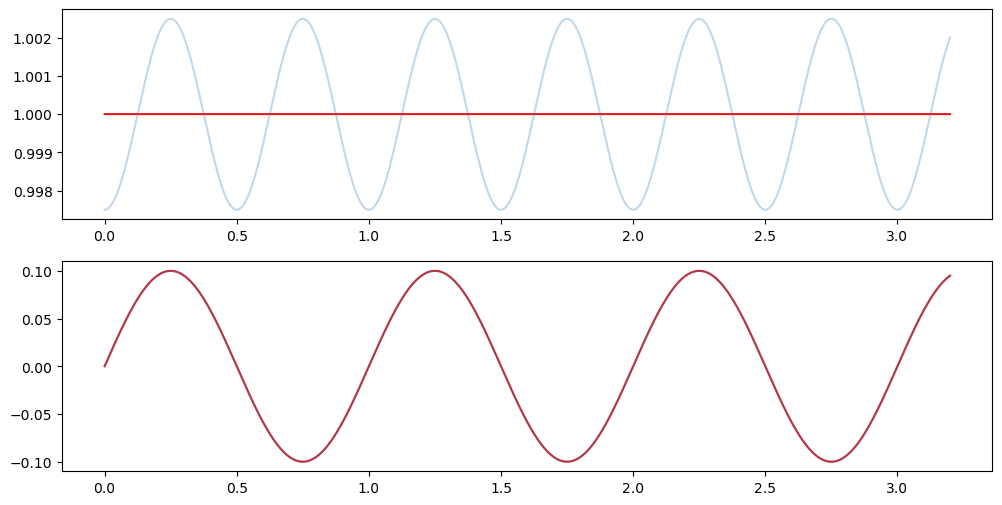

In [10]:
xilinx_1.modulation_depth = 0.1

dt = 10/9830.4
t_gen = np.arange(0, 1.6*2, dt)
s_gen = 1 * np.exp(1j*xilinx_1.modulation_depth*np.sin(2*np.pi*xilinx_1.modulation_frequency_hz/1e6*t_gen))

from scipy.special import jv
s_approx = jv(0, xilinx_1.modulation_depth)
s_approx += jv(1, xilinx_1.modulation_depth) * np.exp(1j*2*np.pi*xilinx_1.modulation_frequency_hz/1e6*t_gen)
s_approx += -jv(1, xilinx_1.modulation_depth) * np.exp(-1j*2*np.pi*xilinx_1.modulation_frequency_hz/1e6*t_gen)

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 1)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

ax0.plot(t_gen, np.abs(s_gen))
ax1.plot(t_gen, np.angle(s_gen))

ax0.plot(t_gen, np.abs(s_approx), alpha=0.3)
ax1.plot(t_gen, np.angle(s_approx), alpha=0.3)

plt.show()

In [11]:
def set_reps(xilinx_1, reps=0):
    pass

xilinx_1.register_sweep(set_reps,
                        reps=1)

In [11]:
carrier_frequency_center = 8.1056e9
carrier_frequency_span = 20e6
carrier_frequency_step = 0.1e6

carrier_frequency_list = np.arange(carrier_frequency_center-carrier_frequency_span/2, carrier_frequency_center+carrier_frequency_span/2+1, carrier_frequency_step)

modulation_frequency_list = np.arange(0, 5e6+1, 1e6)
# modulation_frequency_list = np.array([1e6, 10e6, 20e6])

reps_list = np.arange(0, 10, 1)

print(len(carrier_frequency_list), len(modulation_frequency_list), len(reps_list))

201 6 10


In [ ]:
config_device = [xilinx_1]
config_sweep = [
    [
        [xilinx_1.sweep, 'modulation_frequency_hz', modulation_frequency_list],
        [xilinx_1.sweep, 'modulation_depth', 0.3*np.ones_like(carrier_frequency_list)],
    ],
    [
        [xilinx_1.sweep, 'carrier_frequency_hz', carrier_frequency_list],
    ],
    [
        [xilinx_1.sweep, 'reps', reps_list],
    ],
]

In [ ]:
carrier_frequency_list[2]

In [ ]:
_file_name = 'test_dds_modulation.zarr'
file_name= data_dir / _file_name

do_sweep(config_device, config_sweep, xilinx_1.acquire_decimated, file_name)

# xilinx_1.soc.reset_gens()

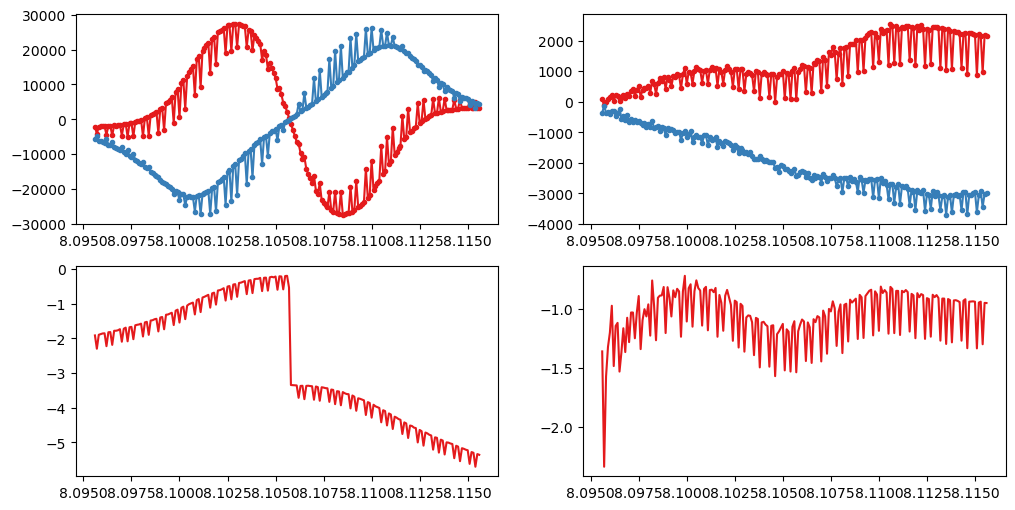

In [7]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated']

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 5e6

for _rox in iq_mat.rfsoc4x2_1_rox:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=0.3, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    p_mean = (s_data * np.conj(s_data) ).mean(dim='rfsoc4x2_1_reps')

    # s_mean = s_data.mean(dim='rfsoc4x2_1_reps')
    # p_mean = s_mean * np.conj(s_mean)

    plot_carrier_frequency = p_mean.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    # s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    # s_pdh = s_demod * p_mean

    if modulation_frequency_hz == 0:
        t_int = p_mean.tx[-1]
    else:
        T_mod = 1e6/modulation_frequency_hz
        # N_period = 1
        N_period = int(p_mean.tx[-1] // T_mod)
        t_int = N_period * T_mod

    idx = np.searchsorted(p_mean.tx.values, t_int, side='right')

    s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    s_demod[idx:] = 0
    s_int = (s_demod * p_mean).mean(dim='rfsoc4x2_1_ticks')

    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).mean(dim='rfsoc4x2_1_ticks')
    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).integrate('tx')

    # s_int = s_pdh.where(s_pdh.tx <= t_int, drop=True).integrate('tx')

    re_pdh = np.real(s_int)
    im_pdh = np.imag(s_int)

    ax0.plot(plot_carrier_frequency, re_pdh, '.-', color='C0')
    ax0.plot(plot_carrier_frequency, im_pdh, '.-', color='C1')

    am_pdh = np.abs(s_int)
    ph_pdh = np.unwrap(np.angle(s_int))

    ax1.plot(plot_carrier_frequency, ph_pdh)

    # ax0.vlines((8.1056e9-modulation_frequency_hz)/1e9, np.min(im_pdh), np.max(im_pdh), color='k')
    # ax0.vlines((8.1056e9+modulation_frequency_hz)/1e9, np.min(im_pdh), np.max(im_pdh), color='k')

plt.show()

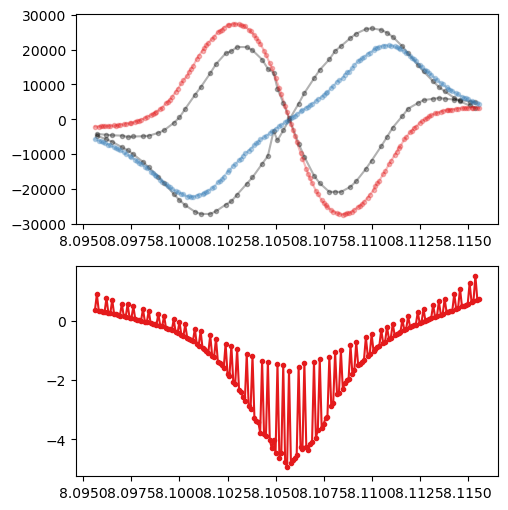

In [55]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated']

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 5e6

for _rox in iq_mat.rfsoc4x2_1_rox[:1]:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=0.3, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    p_mean = (s_data * np.conj(s_data) ).mean(dim='rfsoc4x2_1_reps')

    # s_mean = s_data.mean(dim='rfsoc4x2_1_reps')
    # p_mean = s_mean * np.conj(s_mean)

    plot_carrier_frequency = p_mean.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    # s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    # s_pdh = s_demod * p_mean

    if modulation_frequency_hz == 0:
        t_int = p_mean.tx[-1]
    else:
        T_mod = 1e6/modulation_frequency_hz
        # N_period = 1
        N_period = int(p_mean.tx[-1] // T_mod)
        t_int = N_period * T_mod

    idx = np.searchsorted(p_mean.tx.values, t_int, side='right')

    s_demod = np.exp(1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    s_demod[idx:] = 0
    s_int = (s_demod * p_mean).mean(dim='rfsoc4x2_1_ticks')

    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).mean(dim='rfsoc4x2_1_ticks')
    # s_int = s_pdh.isel(rfsoc4x2_1_ticks=slice(0, idx)).integrate('tx')

    # s_int = s_pdh.where(s_pdh.tx <= t_int, drop=True).integrate('tx')

    re_pdh = np.real(s_int)
    im_pdh = np.imag(s_int)

    # ax0.plot(plot_carrier_frequency, re_pdh, '-', color='C0')
    # ax0.plot(plot_carrier_frequency, im_pdh, '-', color='C1')

    from scipy.signal import savgol_filter, find_peaks
    dphase = (re_pdh/im_pdh).data.compute()

    dphase2 = np.gradient(dphase, plot_carrier_frequency)
    peaks_phase, props = find_peaks(dphase,
                                    distance=1)

    # peaks_phase = np.where(np.abs(dphase2) > 2000)[0]

    all_idx = np.arange(len(plot_carrier_frequency))
    rest_idx = np.setdiff1d(all_idx, peaks_phase)

    ax0.plot(plot_carrier_frequency[peaks_phase], re_pdh[peaks_phase], '.-', color='k', alpha=0.3)
    ax0.plot(plot_carrier_frequency[peaks_phase], im_pdh[peaks_phase], '.-', color='k', alpha=0.3)

    ax0.plot(plot_carrier_frequency[rest_idx], re_pdh[rest_idx], '.-', color='C0', alpha=0.3)
    ax0.plot(plot_carrier_frequency[rest_idx], im_pdh[rest_idx], '.-', color='C1', alpha=0.3)

    # am_pdh = np.abs(s_int)
    # ph_pdh = np.unwrap(np.angle(s_int))

    ax1.plot(plot_carrier_frequency, dphase, '.-')
    # ax1.plot(plot_carrier_frequency[peaks_phase], dphase2[peaks_phase], '.-', color='k', alpha=0.3)
    #
    # ax0.plot(plot_carrier_frequency, np.abs(dphase2), '.-')
    # ax0.plot(plot_carrier_frequency[peaks_phase], np.abs(dphase2)[peaks_phase], '.-', color='k', alpha=0.3)

    # ax0.vlines((8.1056e9-modulation_frequency_hz)/1e9, np.min(im_pdh), np.max(im_pdh), color='k')
    # ax0.vlines((8.1056e9+modulation_frequency_hz)/1e9, np.min(im_pdh), np.max(im_pdh), color='k')

plt.show()

In [ ]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated'].compute()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 0e6

for _rox in iq_mat.rfsoc4x2_1_rox:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=0.3, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    # s_int = s_data.mean(dim='rfsoc4x2_1_ticks')
    plot_carrier_frequency = s_data.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    abs_data = xr.apply_ufunc(np.abs, s_data)
    # abs_mean = xr.apply_ufunc(np.abs, s_data.mean(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps']))
    abs_mean = abs_data.mean(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps'])
    abs_std = abs_data.std(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps'])

    ph_data = xr.apply_ufunc(np.angle,s_data)
    # ph_data = xr.apply_ufunc(np.unwrap,ph_data)

    ph_mean = xr.apply_ufunc(np.angle, s_data.mean(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps']))
    # ph_mean = s_int.mean(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps'])
    ph_std = ph_data.std(dim=['rfsoc4x2_1_ticks', 'rfsoc4x2_1_reps'])

    coef = np.polyfit(plot_carrier_frequency, np.unwrap(ph_mean), 1)
    ph_fit = np.polyval(coef, plot_carrier_frequency)

    ax0.plot(plot_carrier_frequency, abs_mean, '.-', color='C2')
    ax0.fill_between(plot_carrier_frequency,
                     abs_mean-abs_std,
                     abs_mean+abs_std, alpha=0.3, color='C0')

    ax1.plot(plot_carrier_frequency, np.unwrap(ph_mean)-ph_fit, '.-', color='C2')
    ax1.fill_between(plot_carrier_frequency, np.unwrap(ph_mean)-ph_fit-ph_std, np.unwrap(ph_mean)-ph_fit+ph_std, alpha=0.3, color='C0')

plt.show()

In [ ]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated'].load()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

for _rox in iq_mat.rfsoc4x2_1_rox:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=0.3).squeeze()
    ticks = s_data.tx

    carrier_frequency_hz = s_data.rfsoc4x2_1_carrier_frequency_hz.data[1]
    s_trace = s_data.sel(rfsoc4x2_1_carrier_frequency_hz=carrier_frequency_hz, rfsoc4x2_1_modulation_frequency_hz=5e6)

    abs_data = xr.apply_ufunc(np.abs, s_trace)
    # abs_mean = xr.apply_ufunc(np.abs, s_trace.mean(dim='rfsoc4x2_1_reps'))
    abs_mean = abs_data.mean(dim='rfsoc4x2_1_reps')
    abs_std = abs_data.std(dim='rfsoc4x2_1_reps')

    ph_data = xr.apply_ufunc(np.angle,s_trace)
    ph_mean = xr.apply_ufunc(np.angle, s_trace.mean(dim='rfsoc4x2_1_reps'))
    # ph_mean = ph_data.mean(dim='rfsoc4x2_1_reps')
    ph_std = ph_data.std(dim='rfsoc4x2_1_reps')

    ax0.plot(ticks, abs_mean, '.-', color='C2')
    ax0.fill_between(ticks,
                     abs_mean-abs_std,
                     abs_mean+abs_std, alpha=0.3, color='C0')

    ax1.plot(ticks, ph_mean, '.-', color='C2')
    ax1.fill_between(ticks, ph_mean-ph_std, ph_mean+ph_std, alpha=0.3, color='C0')

# ax0.set_xlim(8.100, 8.1043)
# ax1.set_xlim(8.100, 8.1043)

plt.show()


    # plt.figure()
# plt.plot(xilinx_1.config['dr_readout1'].wave.items[0].i_data, '.-')
# plt.plot(xilinx_1.config['dr_readout1'].wave.items[0].q_data, '.-')
# plt.show()

In [ ]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated'].load()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

for _rox in iq_mat.rfsoc4x2_1_rox:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=1, rfsoc4x2_1_modulation_frequency_hz=1e6).squeeze()
    # t_exp = s_data.tx

    s_int = s_data.mean(dim='rfsoc4x2_1_ticks')
    plot_carrier_frequency = s_int.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    abs_data = xr.apply_ufunc(np.abs, s_int)
    abs_mean = xr.apply_ufunc(np.abs, s_int.mean(dim='rfsoc4x2_1_reps'))
    # abs_mean = abs_data.mean(dim='rfsoc4x2_1_reps')
    abs_std = abs_data.std(dim='rfsoc4x2_1_reps')

    ph_data = xr.apply_ufunc(np.angle,s_int)
    # ph_data = xr.apply_ufunc(np.unwrap,ph_data)

    ph_mean = xr.apply_ufunc(np.angle, s_int.mean(dim='rfsoc4x2_1_reps'))
    # ph_mean = s_int.mean(dim='rfsoc4x2_1_reps')
    ph_std = ph_data.std(dim='rfsoc4x2_1_reps')

    coef = np.polyfit(plot_carrier_frequency, np.unwrap(ph_mean), 1)
    ph_fit = np.polyval(coef, plot_carrier_frequency)
    # ph_fit = np.angle(np.exp(1j * ph_fit))

    ax0.plot(plot_carrier_frequency, abs_mean, '.-', color='C2')
    # ax0.fill_between(plot_carrier_frequency,
    #                  abs_mean-abs_std,
    #                  abs_mean+abs_std, alpha=0.3, color='C0')

    ax1.plot(plot_carrier_frequency, np.unwrap(ph_mean)-ph_fit, '.-', color='C2')
    ax1.fill_between(plot_carrier_frequency, np.unwrap(ph_mean)-ph_fit-ph_std, np.unwrap(ph_mean)-ph_fit+ph_std, alpha=0.3, color='C0')

# ax0.set_xlim(8.100, 8.1043)
# ax1.set_xlim(8.100, 8.1043)

plt.show()

In [ ]:
_file_name = 'test_dds_modulation.zarr'

with xr.open_zarr(data_dir / _file_name) as f:
    iq_mat = f['IQ decimated'].load()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2)

modulation_frequency_hz = 1e6

for _rox in iq_mat.rfsoc4x2_1_rox:
    ax0 = fig.add_subplot(gs[0,_rox])
    ax1 = fig.add_subplot(gs[1,_rox])

    s_data = iq_mat.sel(rfsoc4x2_1_rox=_rox, rfsoc4x2_1_modulation_depth=1, rfsoc4x2_1_modulation_frequency_hz=modulation_frequency_hz).squeeze()
    t_exp = s_data.tx

    p_mean = (s_data * np.conj(s_data) ).mean(dim='rfsoc4x2_1_reps')
    plot_carrier_frequency = p_mean.rfsoc4x2_1_carrier_frequency_hz.data/1e9

    s_demod = np.exp(-1j * 2*np.pi * modulation_frequency_hz/1e6 * t_exp)
    s_pdh = s_demod * p_mean

    t_int = 1 * (1e6/s_data.rfsoc4x2_1_modulation_frequency_hz)
    s_int = s_pdh.where(s_pdh.tx <= t_int, drop=True).integrate('tx')

    re_pdh = np.real(s_int)
    im_pdh = np.imag(s_int)

    ax0.plot(plot_carrier_frequency, re_pdh, '.-', color='C2')
    ax1.plot(plot_carrier_frequency, im_pdh, '.-', color='C2')

plt.show()